In [1]:
import torchvision


torchvision.datasets.OxfordIIITPet(root='', download=True)

100%|██████████| 792M/792M [02:20<00:00, 5.65MB/s] 
100%|██████████| 19.2M/19.2M [00:04<00:00, 4.58MB/s]


Dataset OxfordIIITPet
    Number of datapoints: 3680
    Root location: 

In [2]:
import torch
import pathlib
from PIL import  Image
import re
class DatasetOxford():
    def __init__(self, path_data):
        self.path_floder = pathlib.Path(path_data)
        self.image_files = list(self.path_floder.glob('*.jpg'))


    def print_data(self):
        
        for img_path in self.image_files:
            print(f'найден путь к файлу {img_path.name}')
        print(f'найдено {len(self.image_files)} изображений')


    def crate_dataset(self):
        folder_dataset = pathlib.Path('Datsset')
        folder_dataset.mkdir(parents=True, exist_ok=True)
        for img_path in self.image_files:
            cls_name = f'class_{re.sub('[^a-zA-Z]', '', str(img_path.name).replace('jpg','')).lower()}' # оr .stem
            print(cls_name)
            folder_cls = folder_dataset / cls_name
            folder_cls.mkdir(parents=True, exist_ok=True)
            
            print(folder_cls)
            img_path.rename(folder_cls / img_path.name)



            
test = DatasetOxford('oxford-iiit-pet\images')
# test.crate_dataset()





<>:33: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:33: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
C:\Users\royny\AppData\Local\Temp\ipykernel_22400\2589541542.py:33: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  test = DatasetOxford('oxford-iiit-pet\images')


In [5]:
import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader ,random_split, Subset
from torchvision.transforms import v2
from PIL import Image
from sklearn.model_selection import train_test_split


BATCH_SIZE = 128

transform_train = v2.Compose([
    v2.ToImage(),
    v2.Resize(size=(224,224)),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(15),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    v2.ToDtype(dtype=torch.float32, scale=True),
    v2.Normalize(mean=(0.5,0.5, 0.5), std=(0.5,0.5, 0.5))
])
transform_valtest = v2.Compose([
    v2.ToImage(),
    v2.Resize(size=(224,224)),
    v2.ToDtype(dtype=torch.float32, scale=True),
    v2.Normalize(mean=(0.5,0.5, 0.5), std=(0.5,0.5, 0.5))
])

dataset_valtest = ImageFolder('Datsset', transform=transform_valtest)
dataset_train = ImageFolder('Datsset', transform=transform_train)


targets = dataset_train.targets

train_idx, temp_idx = train_test_split(
    range(len(dataset_train)),
    test_size=0.3,
    stratify=targets,
    random_state=42
)

temp_targets = [targets[i] for i in temp_idx]

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.33,
    stratify=temp_targets,
    random_state=42
)

train_dataset = Subset(dataset_train, train_idx)
val_dataset = Subset(dataset_valtest, val_idx)
test_dataset = Subset(dataset_valtest, test_idx)


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


# print(len(dataset))



In [ ]:
import torch
import torch.nn as nn
from tqdm import tqdm
import pathlib

device = "cuda" if torch.cuda.is_available() else 'cpu'

class Bottleneck(nn.Module):
    def __init__(self, inp, out):
        super().__init__()
        mid = out // 4
        self.model = nn.Sequential(
            
            nn.Conv2d(inp, mid, (1,1), bias=False),
            nn.BatchNorm2d(mid),
            nn.ReLU(),
            nn.Conv2d(mid, mid, (3,3), padding=1, bias=False),
            nn.BatchNorm2d(mid),
            nn.ReLU(),
            nn.Conv2d(mid, out, kernel_size=(1,1),bias=False),
            nn.BatchNorm2d(out)
        )
        self.relu = nn.ReLU()

        self.shortcut = nn.Sequential()
        if inp != out:
            self.shortcut = nn.Sequential(
                nn.Conv2d(inp, out, kernel_size=1, bias=False),
                nn.BatchNorm2d(out)
            )
    def forward(self, x):
        indenty = self.shortcut(x)
        x = self.model(x)
        out = self.relu(x+indenty)
        return out

class NewModel(nn.Module):
    def __init__(self, inp, out):
        super().__init__()
        self.init_model = nn.Sequential(
            nn.Conv2d(inp, 64, 7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(3, stride=2, padding=1)
        )

        self.layer1=Bottleneck(64, 128)
        self.pool1 = nn.MaxPool2d(2)
        self.layer2=Bottleneck(128, 256)
        self.pool2 = nn.MaxPool2d(2)
        self.layer3=Bottleneck(256, 512)
        self.pool3 = nn.MaxPool2d(2)
        self.layer4=Bottleneck(512, 1024)
        self.pool4 = nn.MaxPool2d(2)

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))

        self.linear = nn.Sequential(nn.Flatten(),
                                    nn.Linear(1024,512),
                                    nn.ReLU(),
                                    nn.Dropout(0.3),
                                    nn.Linear(512, out))
        
    def forward(self, x):

        x = self.init_model(x)
        x = self.pool1(self.layer1(x))
        x = self.pool2(self.layer2(x))
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        out = self.linear(x)
        return out
        

class ModelNN(nn.Module):
    def __init__(self, inp_ch, out_size):
        super().__init__()
        self.model_conv = nn.Sequential(nn.Conv2d(inp_ch, out_channels=32, kernel_size=(5,5), padding=2,bias=False),
                                        nn.BatchNorm2d(32),
                                        nn.ReLU(),
                                        nn.MaxPool2d(2),
                                        # nn.Dropout2d(0.1),
                                        nn.Conv2d(32,64, kernel_size=(3,3),padding=1, bias=False),
                                        nn.BatchNorm2d(64), 
                                        nn.ReLU(),
                                        nn.MaxPool2d(2),
                                        nn.Conv2d(64,128, kernel_size=(3,3),padding=1, bias=False),
                                        nn.BatchNorm2d(128), 
                                        nn.ReLU(),
                                        nn.MaxPool2d(2),
                                        nn.Conv2d(128,256, kernel_size=(3,3),padding=1, bias=False),
                                        nn.BatchNorm2d(256), 
                                        nn.ReLU(),
                                        nn.MaxPool2d(2),
                                        nn.Conv2d(256,512, kernel_size=(3,3),padding=1, bias=False),
                                        nn.BatchNorm2d(512), 
                                        nn.ReLU(),
                                        nn.MaxPool2d(2),
                                        nn.Conv2d(512,1024, kernel_size=(3,3),padding=1, bias=False),
                                        nn.BatchNorm2d(1024), 
                                        nn.ReLU(),
                                        # nn.MaxPool2d(2),
                                        # nn.Dropout2d(0.1),
                                        nn.AdaptiveAvgPool2d((1,1)))
        

        self.model_linear = nn.Sequential(nn.Linear(1024, 512),
                                          nn.ReLU(),
                                          nn.Dropout(0.2),
                                          nn.Linear(512, out_size))#37
        
        
        self.skip_conv = nn.Sequential(nn.Conv2d(inp_ch, 1024 , kernel_size=(1,1),stride=32),
                                       nn.BatchNorm2d(1024),)

        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()


    def forward(self, x):
        y = self.skip_conv(x)
        x = self.model_conv(x)
        xy = self.relu(x + y)
        xy = self.flatten(xy)
        out = self.model_linear(xy)
        return out
        
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')


torch.cuda.empty_cache()#отчистка кеша 
# model = ModelNN(3, 37).to(device)
# model.apply(init_weights)

model = NewModel(3,37).to(device)
model.apply(init_weights)

opt = torch.optim.Adam(model.parameters(), lr=0.001,weight_decay=1e-4)#weight_decay=1e-4
loss_main = torch.nn.CrossEntropyLoss()

lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt,mode='min',patience=4, factor=0.1)


In [7]:
from torchmetrics.classification import MulticlassPrecision, MulticlassRecall

precision_metrics = MulticlassPrecision(num_classes=37, average='macro').to(device)
recall_metrics = MulticlassRecall(num_classes=37, average='macro').to(device)




In [8]:
'''Early stopping'''

class EarlyStopper:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float('inf')


    def early_stop(self, validation_loss):
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter +=1
            if self.counter >= self.patience:
                return True
        return False

In [9]:
EPOCHS= 150
best_loss = None
#хранение метрик для графиков
val_losses, train_losses, acc_train, acc_val = [],[],[],[]
#директория для сохрранения модели
folder_model = pathlib.Path('saved_model')
folder_model.mkdir(parents=True, exist_ok=True)
#early stopper
early_stopper = EarlyStopper(patience=15, min_delta=1e-4)


for  epoch in range(EPOCHS):
    running_train_loss = []
    true_answer = 0
    train_loop = tqdm(train_loader, leave=False)
    model.train()
    for img, label in train_loop:
        img = img.to(device)
        label = label.to(device)

        pred = model(img)

        opt.zero_grad()
        loss = loss_main(pred, label)

        loss.backward()
        opt.step()

        
        '''metrics'''
        #accuracy
        true_answer += (pred.argmax(dim=1)==label).sum().item()
        running_train_acc = true_answer / len(train_dataset)
        #recall precision

        precision_metrics(pred, label)
        recall_metrics(pred, label)
        epoch_train_precision = precision_metrics.compute().item()
        epoch_train_recall = recall_metrics.compute().item()
        precision_metrics.reset()
        recall_metrics.reset()
        '''loss'''
        running_train_loss.append(loss.item())
        mean_train_loss = sum(running_train_loss) / len(running_train_loss)

        train_loop.set_description(f'loss = {mean_train_loss:.4f} | accuracy = {running_train_acc:.4f} ')     
    train_losses.append(mean_train_loss)
    acc_train.append(running_train_acc)
        
    with torch.no_grad():
        model.eval()
        running_val_loss = []
        true_answer_val = 0
        for img, label in val_loader:
            img = img.to(device)
            label = label.to(device)

            pred = model(img)

            loss = loss_main(pred, label)
            running_val_loss.append(loss.item())
            mean_val_loss = sum(running_val_loss) / len(running_val_loss)



            
            '''-------------metrics-----------------'''
            #accuracy
            true_answer_val += (pred.argmax(dim=1) == label).sum().item()
            running_val_acc = true_answer_val / len(val_dataset)
            #recall presision

            precision_metrics(pred, label)
            recall_metrics(pred, label)

        epoch_val_precision = precision_metrics.compute().item()
        epoch_val_recall = recall_metrics.compute().item()
        precision_metrics.reset()
        recall_metrics.reset()
        lr_scheduler.step(mean_val_loss)#не в цикле валидации иначе упадет лр 

        val_losses.append(mean_val_loss)
        acc_val.append(running_val_acc)
        '''------------------save best model -------------------'''
        if best_loss is None or mean_val_loss < best_loss:
            best_loss = mean_val_loss
            torch.save(model.state_dict(), f'{folder_model}\\best_model')
            print(f'model saved on {epoch+1} epoch with loss = {mean_val_loss:.4f} r = {epoch_val_recall:.4f} p = {epoch_val_recall:.4f}')
            '''-----------------------------------------------------'''

        
        if early_stopper.early_stop(mean_val_loss):
            print("\033[31!!!Обучение остановлено!!!\033[0m")
            break
            
        
        
    
    
        
    print(f'epoch = [{epoch+1} / {EPOCHS}]          | train_loss = {mean_train_loss:.4f} | val_loss = {mean_val_loss:.4f} \
          | accuracy_train = {(true_answer/ len(train_dataset)):.4f} | accuracy_val = {running_val_acc:.4f}\
          |  precision_val = {epoch_val_precision:.4f} | recall_val = {epoch_val_recall:.4f}')

print('model saved')
torch.save(model.state_dict(), f'{folder_model}\\model_final.pt')    
torch.cuda.empty_cache()         

model saved on 1 epoch with loss = 3.5889 r = 0.0463 p = 0.0463
epoch = [1 / 150]          | train_loss = 7.2986 | val_loss = 3.5889           | accuracy_train = 0.0325 | accuracy_val = 0.0465          |  precision_val = 0.0563 | recall_val = 0.0463


model saved on 2 epoch with loss = 3.5780 r = 0.0563 p = 0.0563
epoch = [2 / 150]          | train_loss = 3.6037 | val_loss = 3.5780           | accuracy_train = 0.0336 | accuracy_val = 0.0552          |  precision_val = 0.0235 | recall_val = 0.0563


model saved on 3 epoch with loss = 3.5641 r = 0.0532 p = 0.0532
epoch = [3 / 150]          | train_loss = 3.5967 | val_loss = 3.5641           | accuracy_train = 0.0377 | accuracy_val = 0.0532          |  precision_val = 0.0233 | recall_val = 0.0532


epoch = [4 / 150]          | train_loss = 3.5909 | val_loss = 3.5656           | accuracy_train = 0.0433 | accuracy_val = 0.0579          |  precision_val = 0.0285 | recall_val = 0.0582


model saved on 5 epoch with loss = 3.5429 r = 0.0568 p = 0.0568
epoch = [5 / 150]          | train_loss = 3.5851 | val_loss = 3.5429           | accuracy_train = 0.0390 | accuracy_val = 0.0559          |  precision_val = 0.0405 | recall_val = 0.0568


...

epoch = [114 / 150]          | train_loss = 1.4170 | val_loss = 1.6775           | accuracy_train = 0.5374 | accuracy_val = 0.5051          |  precision_val = 0.5032 | recall_val = 0.5046


epoch = [115 / 150]          | train_loss = 1.4378 | val_loss = 1.6777           | accuracy_train = 0.5266 | accuracy_val = 0.5064          |  precision_val = 0.5032 | recall_val = 0.5059


epoch = [116 / 150]          | train_loss = 1.4276 | val_loss = 1.6787           | accuracy_train = 0.5295 | accuracy_val = 0.5024          |  precision_val = 0.5020 | recall_val = 0.5019


epoch = [117 / 150]          | train_loss = 1.4056 | val_loss = 1.6796           | accuracy_train = 0.5223 | accuracy_val = 0.5044          |  precision_val = 0.5042 | recall_val = 0.5039


[31!!!Обучение остановлено!!!
model saved


In [24]:
tl = train_losses
vl = val_losses

at = acc_train
av = acc_val

142


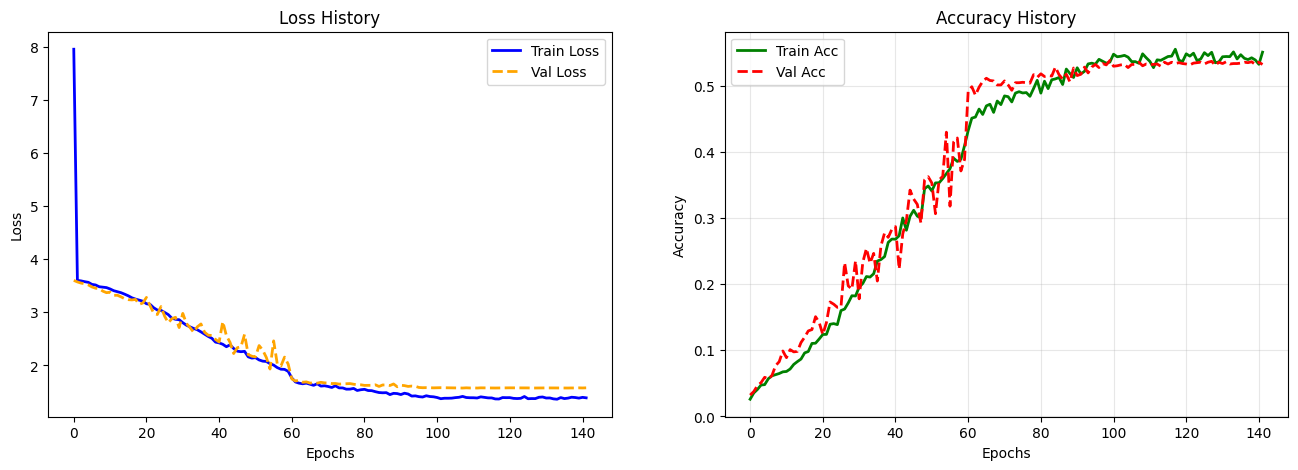

In [8]:
import matplotlib.pyplot as plt


# train_losses = tl+ train_losses
# val_losses = vl + val_losses
# acc_train = at + acc_train
# acc_val = av + acc_val


plt.figure(figsize=(16, 5))
print(len(train_losses))
# 1. График Loss (Потери)
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue', lw=2)
plt.plot(val_losses, label='Val Loss', color='orange', lw=2, linestyle='--')
plt.title('Loss History')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
# plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(acc_train, label='Train Acc', color='green', lw=2)
plt.plot(acc_val, label='Val Acc', color='red', lw=2, linestyle='--')
plt.title('Accuracy History')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [2]:
import torch
from PIL import Image
import random
from matplotlib import pyplot as plt

# transform_valtest = v2.Compose([
#     v2.ToImage(),
#     v2.Resize(size=(224,224)),
#     v2.ToDtype(dtype=torch.float32, scale=True),
#     v2.Normalize(mean=(0.5,0.5, 0.5), std=(0.5,0.5, 0.5))
# ])


def predict_image(model, dataset, class_names):
    idx = random.randint(0, len(dataset_valtest)-1)
    image_tensor, label = dataset_valtest[idx]
    input_tensor = image_tensor.unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad:
        logits = model(input_tensor)


        probs = torch.nn.functional.softmax(logits,dim=1)
        conf, pred = torch.max(probs, 1)

    img_show = image_tensor.premute(1,2,0).cpu().numpy()


    plt.imshow(img_show)
    plt.title(f"True: {class_names[label]}\nPred: {class_names[pred.item()]} ({conf.item()*100:.1f}%)")
    plt.axis('off')
    plt.show()


class_names = [
    'abyssinian', 'americanbulldog', 'americanpitbullterrier', 'bassethound', 
    'beagle', 'bengal', 'birman', 'bombay', 'boxer', 'britishshorthair', 
    'chihuahua', 'egyptianmau', 'englishcockerspaniel', 'englishsetter', 
    'germanshorthaired', 'greatpyrenees', 'havanese', 'japanesechin', 
    'keeshond', 'leonberger', 'mainecoon', 'miniaturepinscher', 'newfoundland', 
    'persian', 'pomeranian', 'pug', 'ragdoll', 'russianblue', 'saintbernard', 
    'samoyed', 'scottishterrier', 'shibainu', 'siamese', 'sphynx', 
    'staffordshirebullterrier', 'wheatenterrier', 'yorkshireterrier'
]

predict_image(model, dataset_valtest, class_names=class_names)

NameError: name 'model' is not defined